# NUTS-2 Geographical Hotspot Analysis

This notebook identifies geographical concentrations of waste hotspots - areas where multiple high-value NUTS-2 regions are spatially close to each other. This helps identify optimal locations for waste recovery infrastructure.

## Workflow
1. Load data and allocate waste to NUTS-2 regions
2. Cluster by Region × NACE × Waste profiles
3. Apply spatial clustering (DBSCAN) to find geographical concentrations
4. Identify cross-border opportunities

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.nuts2 import (
    # Data loading
    load_waste_generation,
    load_sbs_employment,
    load_nuts2_names,
    get_sbs_nuts2_employment,
    # Allocation
    allocate_waste_to_regions,
    add_economic_potential,
    # Clustering
    prepare_clustering_features,
    find_optimal_clusters,
    apply_clustering,
    apply_pca,
    get_cluster_profiles,
    # Geographical analysis
    load_nuts2_centroids,
    find_geographical_hotspots,
    get_hotspot_summary,
    get_cross_border_hotspots,
    calculate_cluster_density,
)

pd.options.display.max_columns = 50
plt.style.use('seaborn-v0_8-whitegrid')

/Users/jimanderssen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load and Prepare Data

In [2]:
# Load waste generation data
wasgen = load_waste_generation()
print(f"Waste generation records: {len(wasgen):,}")
print(f"Countries: {wasgen['country_code'].nunique()}")
print(f"NACE activities: {wasgen['nace_r2'].nunique()}")
print(f"Waste types: {wasgen['waste'].nunique()}")

Waste generation records: 16,408
Countries: 38
NACE activities: 20
Waste types: 43


In [3]:
# Load SBS employment data and NUTS2 names
sbs = load_sbs_employment(use_cache=True)
sbs_nuts2 = get_sbs_nuts2_employment(sbs)
nuts2_names = load_nuts2_names()

print(f"NUTS-2 employment records: {len(sbs_nuts2):,}")
print(f"Unique NUTS-2 regions: {sbs_nuts2['geo'].nunique()}")

NUTS-2 employment records: 34,189
Unique NUTS-2 regions: 371


## 2. Allocate Waste to NUTS-2 Regions

In [4]:
# Allocate national waste to regions based on employment
regional_waste = allocate_waste_to_regions(wasgen, sbs_nuts2, nuts2_names)
regional_waste = add_economic_potential(regional_waste)

print(f"Allocated records: {len(regional_waste):,}")
print(f"Unique NUTS-2 regions: {regional_waste['nuts2_region'].nunique()}")
print(f"Total waste: {regional_waste['allocated_waste_tonnes'].sum()/1e9:.2f} billion tonnes")
print(f"Total economic potential: €{regional_waste['economic_potential_eur'].sum()/1e9:.1f} billion")

Allocated records: 192,047
Unique NUTS-2 regions: 371
Total waste: 10.54 billion tonnes
Total economic potential: €1358.6 billion


## 3. Cluster by Waste Profile

In [5]:
# Prepare features and find optimal clusters
cluster_base, X_scaled, scaler = prepare_clustering_features(regional_waste)
print(f"Clustering {len(cluster_base):,} Region × NACE × Waste combinations")

best_k, silhouettes, inertias = find_optimal_clusters(X_scaled)
print(f"Optimal k by silhouette: {best_k}")

Clustering 192,047 Region × NACE × Waste combinations
Optimal k by silhouette: 3


In [6]:
# Apply clustering with 3 tiers (0=lowest, 2=highest value)
n_clusters = 3
clustered_data, kmeans = apply_clustering(cluster_base, X_scaled, n_clusters=n_clusters)

print(f"\nCluster distribution:")
for c in range(n_clusters):
    subset = clustered_data[clustered_data['cluster'] == c]
    print(f"  Cluster {c}: {len(subset):,} combos, "
          f"avg €{subset['economic_potential_eur'].mean()/1e6:.1f}M, "
          f"avg {subset['allocated_waste_tonnes'].mean()/1e3:.1f}k tonnes")


Cluster distribution:
  Cluster 0: 82,301 combos, avg €0.0M, avg 0.3k tonnes
  Cluster 1: 72,785 combos, avg €6.7M, avg 127.3k tonnes
  Cluster 2: 36,961 combos, avg €23.6M, avg 33.8k tonnes


## 4. Geographical Hotspot Analysis

Now we identify spatial clusters where multiple high-value regions are geographically close. 

Uses **hierarchical clustering with complete linkage** to ensure all regions within a cluster are within the max diameter - this prevents the "chaining" problem where DBSCAN connects distant regions through intermediaries.

In [7]:
# Load NUTS2 centroids
centroids = load_nuts2_centroids()
print(f"Loaded {len(centroids)} NUTS2 centroids")
centroids.head(10)

Loaded 282 NUTS2 centroids


,nuts2_region,lat,lon
0,AT11,47.50,16.50
1,AT12,48.20,15.75
2,AT13,48.20,16.37
3,AT21,46.90,14.50
4,AT22,47.10,15.40
5,AT31,48.30,14.25
6,AT32,47.30,11.50
7,AT33,47.10,10.00
8,AT34,47.10,13.10
9,BE10,50.85,4.35


In [8]:
# Find geographical hotspots among high-value cluster (cluster 2)
# max_diameter_km: maximum distance between ANY two regions in a cluster
# min_regions: minimum regions to form a cluster

min_cluster_threshold = 2  # Only the highest cluster (with 3 clusters total)

geo_hotspots = find_geographical_hotspots(
    clustered_data,
    min_cluster=min_cluster_threshold,
    max_diameter_km=400,   # All regions must be within 400km of each other
    min_regions=3,         # At least 3 regions per cluster
    aggregate_by='region',
    method='hierarchical'  # Prevents chaining problem
)

print(f"\nRegions in geographical clusters: {(geo_hotspots['geo_cluster'] >= 0).sum()}\"")
print(f"Isolated high-value regions: {(geo_hotspots['geo_cluster'] == -1).sum()}")

Found 39 geographical clusters, 26 isolated/small-cluster regions

Regions in geographical clusters: 256"
Isolated high-value regions: 26


In [9]:
# Summary of geographical hotspot clusters
hotspot_summary = get_hotspot_summary(geo_hotspots)
print("Geographical Hotspot Clusters (by economic potential):")
print("=" * 80)
for _, row in hotspot_summary.iterrows():
    print(f"\nGeo-Cluster {int(row['geo_cluster'])}: {int(row['n_regions'])} regions")
    print(f"  Countries: {row['countries']}")
    print(f"  Economic potential: €{row['total_economic_eur']/1e9:.2f}B")
    print(f"  Total waste: {row['total_waste_tonnes']/1e9:.2f}B tonnes")
    print(f"  Centroid: ({row['centroid_lat']:.2f}°N, {row['centroid_lon']:.2f}°E)")
    print(f"  Regions: {row['regions']}")

Geographical Hotspot Clusters (by economic potential):

Geo-Cluster 3: 29 regions
  Countries: BE, DE, FR, NL
  Economic potential: €85.97B
  Total waste: 0.12B tonnes
  Centroid: (51.34°N, 5.28°E)
  Regions: BE10, BE21, BE22, BE23, BE24, BE25, BE31, BE32, BE33, BE34, BE35, DEA1, DEA2, DEA3, DEA4, FRE1, FRE2, NL11, NL12, NL13, NL21, NL22, NL23, NL31, NL32, NL33, NL34, NL41, NL42

Geo-Cluster 35: 16 regions
  Countries: UK
  Economic potential: €46.04B
  Total waste: 0.07B tonnes
  Centroid: (53.42°N, -1.77°E)
  Regions: UKC1, UKC2, UKD1, UKD3, UKD4, UKD6, UKD7, UKE1, UKE2, UKE3, UKE4, UKF1, UKF2, UKG1, UKG2, UKG3

Geo-Cluster 36: 13 regions
  Countries: UK
  Economic potential: €40.29B
  Total waste: 0.06B tonnes
  Centroid: (51.56°N, -0.28°E)
  Regions: UKF3, UKH1, UKH2, UKH3, UKI3, UKI4, UKI5, UKI6, UKI7, UKJ1, UKJ2, UKJ3, UKJ4

Geo-Cluster 20: 5 regions
  Countries: FR
  Economic potential: €31.14B
  Total waste: 0.04B tonnes
  Centroid: (47.67°N, 4.57°E)
  Regions: FR10, FRB0, FRC1

In [10]:
# Calculate density of each geographical cluster
density = calculate_cluster_density(geo_hotspots)
print("\nGeographical clusters by economic density:")
density


Geographical clusters by economic density:


,geo_cluster,n_regions,area_km2,total_economic_eur,density_eur_per_km2
26,26,4,9547.879605,2.251234e+10,2.357837e+06
36,36,13,28189.866107,4.028940e+10,1.429216e+06
8,8,6,16979.105912,2.108521e+10,1.241833e+06
35,35,16,40086.064189,4.604248e+10,1.148591e+06
3,3,29,120375.891648,8.596954e+10,7.141757e+05
37,37,6,28431.498825,1.593478e+10,5.604622e+05
28,28,3,7572.817035,4.234012e+09,5.591066e+05
33,33,4,38035.584240,1.981529e+10,5.209672e+05
0,0,8,42566.650925,2.087440e+10,4.903932e+05
20,20,5,63658.407147,3.113523e+10,4.890985e+05


## 5. Cross-Border Hotspots

Identify geographical clusters that span multiple countries - potential for cross-border waste recovery cooperation.

In [11]:
# Find cross-border hotspots
cross_border = get_cross_border_hotspots(geo_hotspots, min_countries=2)

if len(cross_border) > 0:
    print(f"Cross-border hotspots: {cross_border['geo_cluster'].nunique()} clusters")
    print(f"Regions involved: {len(cross_border)}")
    
    # Summary by cluster
    for cluster_id in cross_border['geo_cluster'].unique():
        cluster_data = cross_border[cross_border['geo_cluster'] == cluster_id]
        countries = sorted(cluster_data['country_code'].unique())
        total_value = cluster_data['total_economic_eur'].sum()
        
        print(f"\nCross-border cluster {cluster_id}:")
        print(f"  Countries: {', '.join(countries)}")
        print(f"  Regions: {len(cluster_data)}")
        print(f"  Economic potential: €{total_value/1e9:.2f}B")
        
        for _, row in cluster_data.iterrows():
            print(f"    {row['nuts2_region']} ({row['country_code']}): {row['nuts2_name']} - €{row['total_economic_eur']/1e9:.2f}B")
else:
    print("No cross-border hotspots found with current parameters")

Cross-border hotspots: 14 clusters
Regions involved: 117

Cross-border cluster 0:
  Countries: AT, CZ, HU, SK
  Regions: 8
  Economic potential: €20.87B
    AT11 (AT): Burgenland - €0.71B
    AT12 (AT): Niederösterreich - €5.05B
    AT13 (AT): Wien - €3.46B
    CZ06 (CZ): Jihovýchod - €4.17B
    HU21 (HU): Közép-Dunántúl - €1.56B
    HU22 (HU): Nyugat-Dunántúl - €1.24B
    SK01 (SK): Bratislavský kraj - €1.14B
    SK02 (SK): Západné Slovensko - €3.54B

Cross-border cluster 1:
  Countries: AT, IT, SI
  Regions: 10
  Economic potential: €27.40B
    AT21 (AT): Kärnten - €1.89B
    AT22 (AT): Steiermark - €4.89B
    AT31 (AT): Oberösterreich - €6.62B
    AT34 (AT): Vorarlberg - €1.71B
    ITH1 (IT): Provincia Autonoma di Bolzano/Bozen - €0.54B
    ITH2 (IT): Provincia Autonoma di Trento - €0.57B
    ITH3 (IT): Veneto - €7.02B
    ITH4 (IT): Friuli-Venezia Giulia - €1.52B
    SI03 (SI): Vzhodna Slovenija - €1.52B
    SI04 (SI): Zahodna Slovenija - €1.12B

Cross-border cluster 2:
  Countries

## 6. Visualize Geographical Hotspots

cartopy not installed, using plain plot. Install with: pip install cartopy


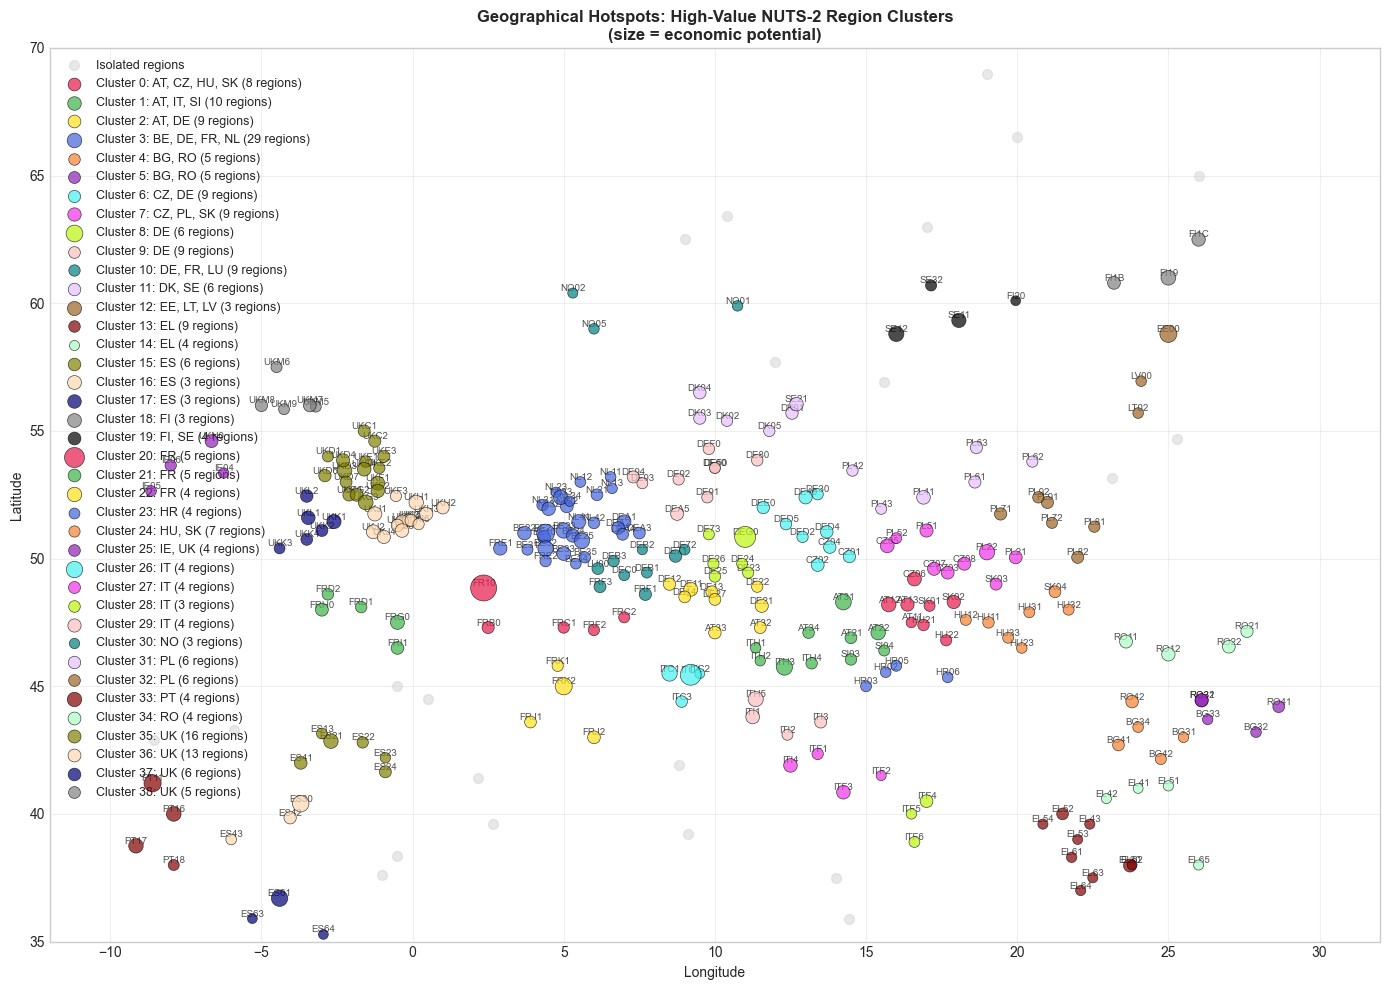

In [12]:
# Map visualization of geographical hotspots with Europe basemap
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    use_cartopy = True
except ImportError:
    print("cartopy not installed, using plain plot. Install with: pip install cartopy")
    use_cartopy = False

if use_cartopy:
    # EPSG:3035 - ETRS89-LAEA Europe (official Eurostat projection)
    projection = ccrs.epsg(3035)
    
    fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={'projection': projection})
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666666')
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='#999999', linestyle='-')
    ax.add_feature(cfeature.LAKES, facecolor='#e6f3ff', edgecolor='#999999', linewidth=0.3)
    
    # Set extent using EPSG:3035 coordinates (roughly covering EU)
    ax.set_extent([2500000, 6500000, 1500000, 5500000], crs=projection)
else:
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(-12, 32)
    ax.set_ylim(35, 70)

# Data coordinate reference system (lat/lon)
data_crs = ccrs.PlateCarree() if use_cartopy else None

# Plot isolated regions (noise) in gray
isolated = geo_hotspots[geo_hotspots['geo_cluster'] == -1]
scatter_kwargs = {'transform': data_crs, 'zorder': 5} if use_cartopy else {'zorder': 5}
ax.scatter(isolated['lon'], isolated['lat'], 
           c='lightgray', s=50, alpha=0.5, label='Isolated regions', **scatter_kwargs)

# Plot clustered regions with distinct colors
clustered = geo_hotspots[geo_hotspots['geo_cluster'] >= 0]

# Use a qualitative colormap with distinct colors
distinct_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
    '#008080', '#e6beff', '#9a6324', '#800000', '#aaffc3',
    '#808000', '#ffd8b1', '#000075', '#808080', '#000000'
]

for i, cluster_id in enumerate(sorted(clustered['geo_cluster'].unique())):
    cluster_data = clustered[clustered['geo_cluster'] == cluster_id]
    
    # Get countries for this cluster
    countries = ', '.join(sorted(cluster_data['country_code'].unique()))
    
    # Size by economic potential
    sizes = (cluster_data['total_economic_eur'] / clustered['total_economic_eur'].max() * 300) + 50
    
    color = distinct_colors[i % len(distinct_colors)]
    scatter_kwargs = {'transform': data_crs, 'zorder': 10} if use_cartopy else {'zorder': 10}
    ax.scatter(cluster_data['lon'], cluster_data['lat'],
               c=color, s=sizes, alpha=0.7,
               label=f'Cluster {cluster_id}: {countries} ({len(cluster_data)} regions)',
               edgecolors='black', linewidths=0.5, **scatter_kwargs)
    
    # Label regions in each cluster
    for _, row in cluster_data.iterrows():
        if use_cartopy:
            ax.text(row['lon'], row['lat'], row['nuts2_region'],
                    fontsize=7, ha='center', va='bottom', alpha=0.8,
                    transform=data_crs, zorder=11)
        else:
            ax.annotate(row['nuts2_region'], (row['lon'], row['lat']),
                        fontsize=7, ha='center', va='bottom', alpha=0.8)

ax.set_title('Geographical Hotspots: High-Value NUTS-2 Region Clusters\n(size = economic potential)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)

if not use_cartopy:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nuts2_geographical_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Detailed Analysis by Geographical Cluster

In [13]:
# For each geographical cluster, show the waste types and NACE activities
# that make these regions high-value

# First, link back to the detailed clustered data
high_value_detail = clustered_data[clustered_data['cluster'] >= min_cluster_threshold].copy()

# Add geo_cluster assignment
geo_mapping = geo_hotspots[['nuts2_region', 'geo_cluster']].drop_duplicates()
high_value_detail = high_value_detail.merge(geo_mapping, on='nuts2_region', how='left')

print("Waste profile breakdown by geographical cluster:")
print("=" * 80)

for geo_cluster in sorted(geo_hotspots[geo_hotspots['geo_cluster'] >= 0]['geo_cluster'].unique()):
    cluster_detail = high_value_detail[high_value_detail['geo_cluster'] == geo_cluster]
    cluster_regions = geo_hotspots[geo_hotspots['geo_cluster'] == geo_cluster]
    
    print(f"\n--- Geo-Cluster {geo_cluster} ---")
    print(f"Regions: {', '.join(sorted(cluster_regions['nuts2_region'].unique()))}\"")
    print(f"Countries: {', '.join(sorted(cluster_regions['country_code'].unique()))}\"")
    
    # Top waste types
    top_waste = cluster_detail.groupby(['waste', 'waste_description'])['economic_potential_eur'].sum().nlargest(5)
    print("\nTop waste types:")
    for (waste, desc), value in top_waste.items():
        print(f"  {waste}: {value/1e9:.2f}B - {desc[:50]}")
    
    # Top NACE activities
    top_nace = cluster_detail.groupby(['nace_r2', 'nace_activity'])['economic_potential_eur'].sum().nlargest(5)
    print("\nTop NACE activities:")
    for (nace, activity), value in top_nace.items():
        print(f"  {nace}: {value/1e9:.2f}B - {activity[:50]}")

Waste profile breakdown by geographical cluster:

--- Geo-Cluster 0 ---
Regions: AT11, AT12, AT13, CZ06, HU21, HU22, SK01, SK02"
Countries: AT, CZ, HU, SK"

Top waste types:
  W06_07A: 7.76B - Recyclable wastes (subtotal, W06+W07 except W077)
  W061: 6.39B - Metal wastes, ferrous
  W06: 3.56B - Metallic wastes (W061+W062+W063)
  W072: 2.00B - Paper and cardboard wastes
  W062: 0.71B - Metal wastes, non-ferrous

Top NACE activities:
  C: 8.15B - Manufacturing
  G-U_X_G4677: 2.47B - Services (except wholesale of waste and scrap)
  C26-C30: 2.45B - Manufacture of computer, electronic and optical pr
  C24_C25: 2.40B - Manufacture of basic metals and fabricated metal p
  E38: 1.17B - Waste collection, treatment and disposal activitie

--- Geo-Cluster 1 ---
Regions: AT21, AT22, AT31, AT34, ITH1, ITH2, ITH3, ITH4, SI03, SI04"
Countries: AT, IT, SI"

Top waste types:
  W06_07A: 11.66B - Recyclable wastes (subtotal, W06+W07 except W077)
  W061: 7.13B - Metal wastes, ferrous
  W06: 4.55B - Metal

## 8. Export Results

In [14]:
# Export geographical hotspot data
geo_hotspots.to_csv('../data/processed/nuts2_geographical_hotspots.csv', index=False)
print(f"Saved: data/processed/nuts2_geographical_hotspots.csv ({len(geo_hotspots)} records)")

# Export summary
hotspot_summary.to_csv('../data/processed/nuts2_geo_hotspot_summary.csv', index=False)
print(f"Saved: data/processed/nuts2_geo_hotspot_summary.csv")

# Export detailed data with geo-cluster assignment
high_value_detail.to_csv('../data/processed/nuts2_high_value_with_geo.csv', index=False)
print(f"Saved: data/processed/nuts2_high_value_with_geo.csv ({len(high_value_detail)} records)")

Saved: data/processed/nuts2_geographical_hotspots.csv (282 records)
Saved: data/processed/nuts2_geo_hotspot_summary.csv
Saved: data/processed/nuts2_high_value_with_geo.csv (36961 records)


In [15]:
# Summary
print("\n" + "=" * 70)
print("GEOGRAPHICAL HOTSPOT ANALYSIS SUMMARY")
print("=" * 70)
print(f"Total high-value regions analyzed: {len(geo_hotspots)}")
print(f"Geographical clusters found: {(geo_hotspots['geo_cluster'] >= 0).nunique() - 1}")
print(f"Regions in clusters: {(geo_hotspots['geo_cluster'] >= 0).sum()}")
print(f"Isolated regions: {(geo_hotspots['geo_cluster'] == -1).sum()}")

if len(cross_border) > 0:
    print(f"\nCross-border clusters: {cross_border['geo_cluster'].nunique()}")
    print(f"Cross-border regions: {len(cross_border)}")

print(f"\nTotal economic potential in clusters: €{geo_hotspots[geo_hotspots['geo_cluster'] >= 0]['total_economic_eur'].sum()/1e9:.1f}B")


GEOGRAPHICAL HOTSPOT ANALYSIS SUMMARY
Total high-value regions analyzed: 282
Geographical clusters found: 1
Regions in clusters: 256
Isolated regions: 26

Cross-border clusters: 14
Cross-border regions: 117

Total economic potential in clusters: €650.1B
